In [2]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

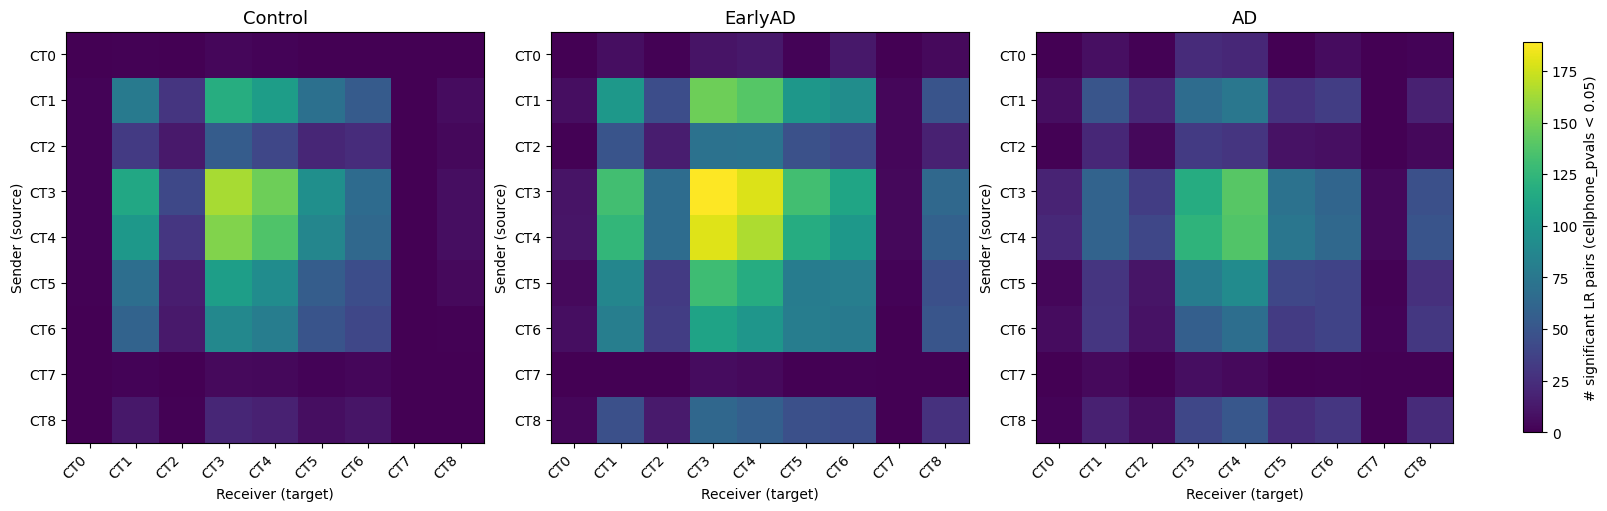

In [ ]:
# fig.title("Heatmap of significant LR pairs per (sender→receiver) using cellphone_pvals < 0.05")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


paths = {
    "Control":  "/content/drive/MyDrive/PhD Research/TiissueAgent/Cell-cell communication/lr_results_control.csv",
    "EarlyAD":  "/content/drive/MyDrive/PhD Research/TiissueAgent/Cell-cell communication/lr_results_earlyAD.csv",
    "AD":       "/content/drive/MyDrive/PhD Research/TiissueAgent/Cell-cell communication/lr_results_AD.csv",
}

# Optional: replace these with your real cell-type names in index order 0..8
# Example:
# celltype_names = ["Astro", "Micro", "Oligo", ...]  # length must match max id + 1
celltype_names = None

metric = "count_sig"   # "count_sig" or "sum_strength"
p_thr  = 0.05          # threshold for cellphone_pvals
use_pval_filter_for_strength = True  # only used if metric="sum_strength"


dfs = {stage: pd.read_csv(fp) for stage, fp in paths.items()}

def build_sender_receiver_matrix(
    df: pd.DataFrame,
    sources,
    targets,
    metric: str = "count_sig",
    p_thr: float = 0.05,
    use_pval_filter_for_strength: bool = True,
):
    """
    Returns a (len(sources) x len(targets)) matrix with rows=sources, cols=targets.
    """
    d = df.copy()

    # Ensure ints (your files already are, but just in case)
    d["source"] = d["source"].astype(int)
    d["target"] = d["target"].astype(int)

    if metric == "count_sig":
        d = d[d["cellphone_pvals"] < p_thr]
        agg = d.groupby(["source", "target"]).size().rename("weight")

    elif metric == "sum_strength":
        # strength: larger = stronger; magnitude_rank is 0..1 (smaller rank = better)
        d["strength"] = 1.0 - d["magnitude_rank"].astype(float)
        if use_pval_filter_for_strength:
            d = d[d["cellphone_pvals"] < p_thr]
        agg = d.groupby(["source", "target"])["strength"].sum().rename("weight")

    else:
        raise ValueError(f"Unknown metric: {metric}")

    # Fill into dense matrix
    mat = np.zeros((len(sources), len(targets)), dtype=float)
    idx = {s: i for i, s in enumerate(sources)}
    jdx = {t: j for j, t in enumerate(targets)}

    for (s, t), w in agg.items():
        if s in idx and t in jdx:
            mat[idx[s], jdx[t]] = float(w)

    return mat

# Determine consistent ordering across stages (0..8 in your case)
all_sources = sorted(set(np.concatenate([df["source"].unique() for df in dfs.values()])))
all_targets = sorted(set(np.concatenate([df["target"].unique() for df in dfs.values()])))

# Labels
if celltype_names is None:
    xlabels = [f"CT{t}" for t in all_targets]
    ylabels = [f"CT{s}" for s in all_sources]
else:
    # assumes celltype_names is list where index matches the integer id
    xlabels = [celltype_names[t] for t in all_targets]
    ylabels = [celltype_names[s] for s in all_sources]

# Build matrices for each stage
mats = {
    stage: build_sender_receiver_matrix(
        df,
        sources=all_sources,
        targets=all_targets,
        metric=metric,
        p_thr=p_thr,
        use_pval_filter_for_strength=use_pval_filter_for_strength,
    )
    for stage, df in dfs.items()
}

# Use a shared color scale so panels are comparable
vmin = min(mat.min() for mat in mats.values())
vmax = max(mat.max() for mat in mats.values())


fig, axes = plt.subplots(1, len(mats), figsize=(16, 5), constrained_layout=True)

if len(mats) == 1:
    axes = [axes]

for ax, (stage, mat) in zip(axes, mats.items()):
    im = ax.imshow(mat, aspect="auto", vmin=vmin, vmax=vmax)

    ax.set_title(stage, fontsize=13)
    ax.set_xlabel("Receiver (target)")
    ax.set_ylabel("Sender (source)")

    ax.set_xticks(np.arange(len(all_targets)))
    ax.set_yticks(np.arange(len(all_sources)))
    ax.set_xticklabels(xlabels, rotation=45, ha="right")
    ax.set_yticklabels(ylabels)

    # Optional: annotate each cell with value (turn off if too dense)
    # for i in range(mat.shape[0]):
    #     for j in range(mat.shape[1]):
    #         if mat[i, j] > 0:
    #             ax.text(j, i, f"{mat[i,j]:.0f}" if metric=="count_sig" else f"{mat[i,j]:.2f}",
    #                     ha="center", va="center", fontsize=7)

# One shared colorbar
cbar = fig.colorbar(im, ax=axes, shrink=0.95)
if metric == "count_sig":
    cbar.set_label(f"# significant LR pairs (cellphone_pvals < {p_thr})")
else:
    cbar.set_label("Sum strength = Σ(1 - magnitude_rank)")

plt.show()


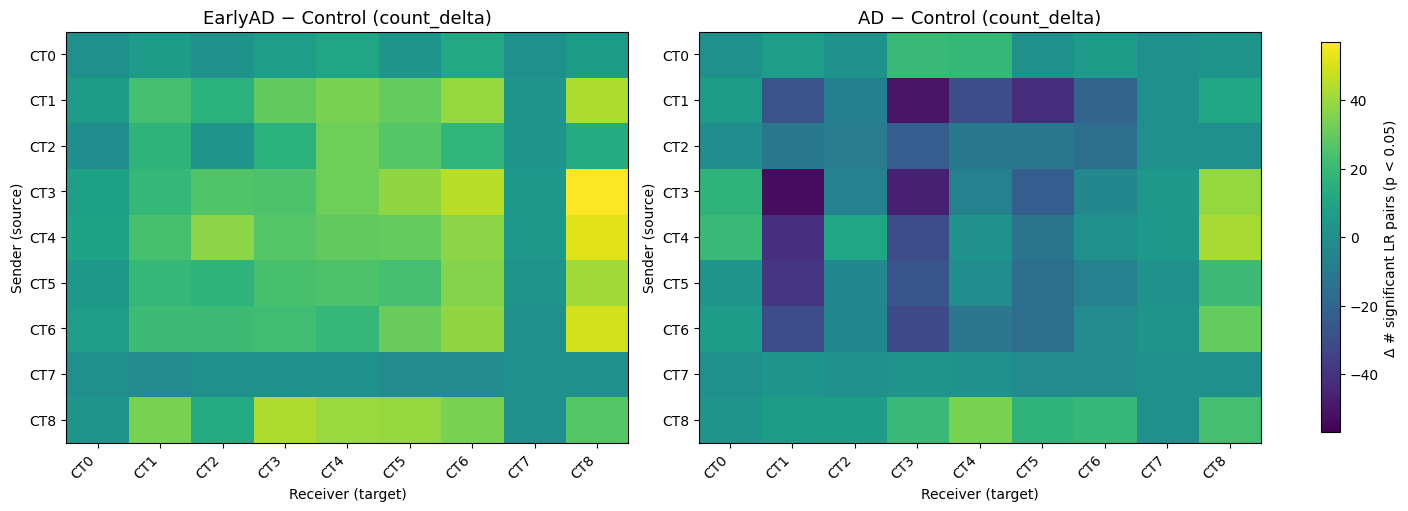

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


paths = {
    "Control":  "/content/drive/MyDrive/PhD Research/TiissueAgent/Cell-cell communication/lr_results_control.csv",
    "EarlyAD":  "/content/drive/MyDrive/PhD Research/TiissueAgent/Cell-cell communication/lr_results_earlyAD.csv",
    "AD":       "/content/drive/MyDrive/PhD Research/TiissueAgent/Cell-cell communication/lr_results_AD.csv",
}

# Optional: replace with real names for CT0..CT8
celltype_names = None  # e.g. ["Astro", "Micro", ..., "Endo"]

# -------------------------
# 1) Settings
# -------------------------
p_thr = 0.05

# Choose differential mode:
#   "count_delta" : ( #sig in stage ) - ( #sig in control )
#   "frac_delta"  : ( frac sig in stage ) - ( frac sig in control )
diff_mode = "count_delta"


dfs = {stage: pd.read_csv(fp) for stage, fp in paths.items()}

def build_edge_matrices(df, sources, targets, p_thr=0.05):
    """
    Returns two dense matrices:
      total_mat[s,t] = number of LR tests for (source=s,target=t) in this file
      sig_mat[s,t]   = number of significant LR (cellphone_pvals < p_thr)
    """
    d = df.copy()
    d["source"] = d["source"].astype(int)
    d["target"] = d["target"].astype(int)

    # total counts per edge (how many rows exist for that source-target)
    total = d.groupby(["source", "target"]).size()

    # significant counts per edge
    sig = d.loc[d["cellphone_pvals"] < p_thr].groupby(["source", "target"]).size()

    # fill dense
    S, T = len(sources), len(targets)
    total_mat = np.zeros((S, T), dtype=float)
    sig_mat   = np.zeros((S, T), dtype=float)

    s_idx = {s:i for i, s in enumerate(sources)}
    t_idx = {t:j for j, t in enumerate(targets)}

    for (s, t), v in total.items():
        if s in s_idx and t in t_idx:
            total_mat[s_idx[s], t_idx[t]] = float(v)

    for (s, t), v in sig.items():
        if s in s_idx and t in t_idx:
            sig_mat[s_idx[s], t_idx[t]] = float(v)

    return total_mat, sig_mat

# Consistent ordering across stages
all_sources = sorted(set(np.concatenate([df["source"].unique() for df in dfs.values()])))
all_targets = sorted(set(np.concatenate([df["target"].unique() for df in dfs.values()])))

if celltype_names is None:
    xlabels = [f"CT{t}" for t in all_targets]
    ylabels = [f"CT{s}" for s in all_sources]
else:
    xlabels = [celltype_names[t] for t in all_targets]
    ylabels = [celltype_names[s] for s in all_sources]

# Build total/sig matrices for each stage
mats = {}
for stage, df in dfs.items():
    total_mat, sig_mat = build_edge_matrices(df, all_sources, all_targets, p_thr=p_thr)
    mats[stage] = {"total": total_mat, "sig": sig_mat}


control_total = mats["Control"]["total"]
control_sig   = mats["Control"]["sig"]

def safe_divide(a, b):
    out = np.zeros_like(a, dtype=float)
    mask = b > 0
    out[mask] = a[mask] / b[mask]
    return out

def delta_matrix(stage_name: str, mode: str):
    st_total = mats[stage_name]["total"]
    st_sig   = mats[stage_name]["sig"]

    if mode == "count_delta":
        return st_sig - control_sig

    if mode == "frac_delta":
        st_frac = safe_divide(st_sig, st_total)
        ct_frac = safe_divide(control_sig, control_total)
        return st_frac - ct_frac

    raise ValueError(f"Unknown diff_mode: {mode}")

delta_early = delta_matrix("EarlyAD", diff_mode)
delta_ad    = delta_matrix("AD", diff_mode)

# Shared symmetric color scale (centered at 0)
absmax = max(np.abs(delta_early).max(), np.abs(delta_ad).max())
vmin, vmax = -absmax, absmax


fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

titles = [f"EarlyAD − Control ({diff_mode})", f"AD − Control ({diff_mode})"]
for ax, mat, title in zip(axes, [delta_early, delta_ad], titles):
    im = ax.imshow(mat, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Receiver (target)")
    ax.set_ylabel("Sender (source)")

    ax.set_xticks(np.arange(len(all_targets)))
    ax.set_yticks(np.arange(len(all_sources)))
    ax.set_xticklabels(xlabels, rotation=45, ha="right")
    ax.set_yticklabels(ylabels)

# One shared colorbar
cbar = fig.colorbar(im, ax=axes, shrink=0.95)
if diff_mode == "count_delta":
    cbar.set_label(f"Δ # significant LR pairs (p < {p_thr})")
else:
    cbar.set_label(f"Δ fraction significant (p < {p_thr})")

plt.show()


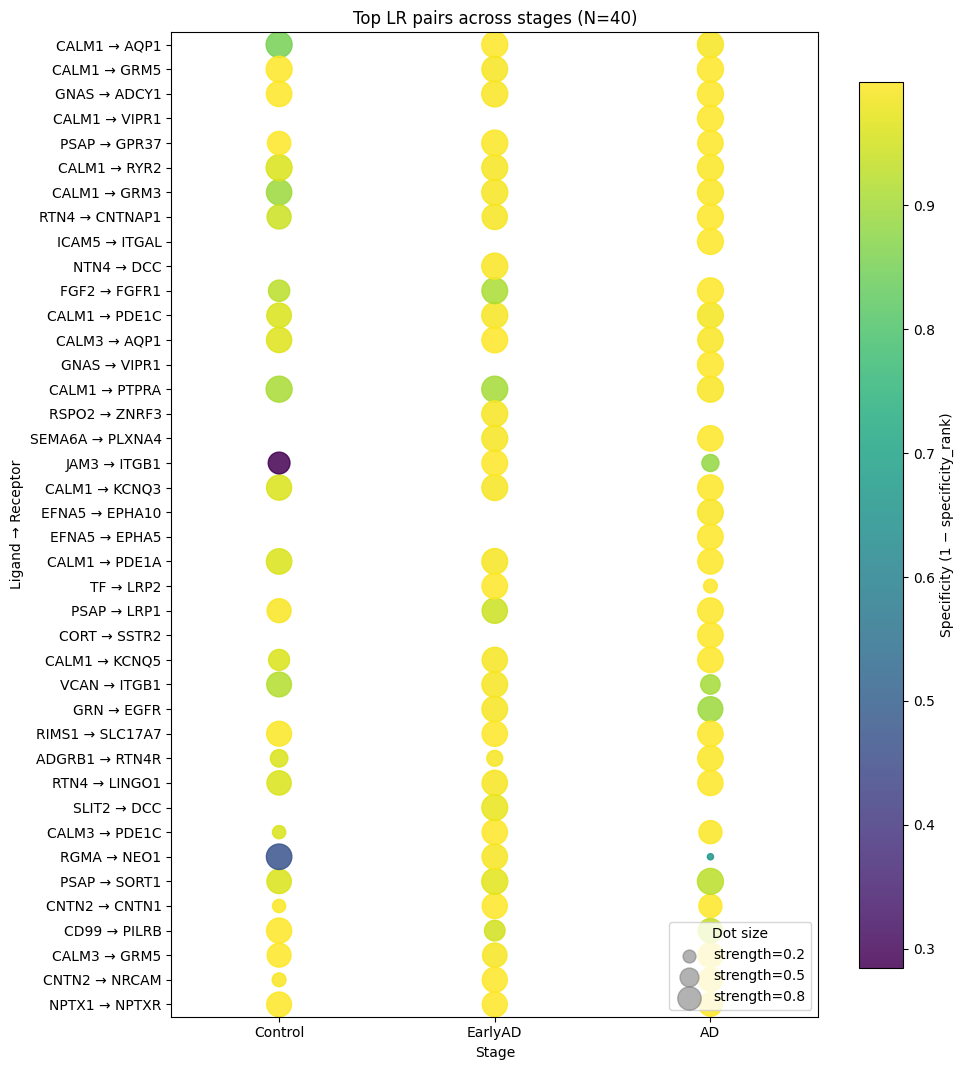

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


paths = {
    "Control":  "/content/drive/MyDrive/PhD Research/TiissueAgent/Cell-cell communication/lr_results_control.csv",
    "EarlyAD":  "/content/drive/MyDrive/PhD Research/TiissueAgent/Cell-cell communication/lr_results_earlyAD.csv",
    "AD":       "/content/drive/MyDrive/PhD Research/TiissueAgent/Cell-cell communication/lr_results_AD.csv",
}

# Pick how many LR pairs to show
top_n_total = 40            # final number of rows on the plot
top_n_per_stage = 25        # used to form the union of candidates

# Filtering (recommended)
p_thr = 0.05                # only consider LR pairs with best_pval < p_thr for ranking
require_sig_for_ranking = True

# Plot encodings
color_by = "specificity"    # "specificity" or "neglog10p"
size_by  = "strength"       # currently only "strength" implemented


dfs = []
for stage, fp in paths.items():
    df = pd.read_csv(fp)
    df["stage"] = stage
    dfs.append(df)
all_df = pd.concat(dfs, ignore_index=True)

# Make sure numeric columns are numeric
for col in ["magnitude_rank", "specificity_rank", "cellphone_pvals"]:
    all_df[col] = pd.to_numeric(all_df[col], errors="coerce")

# LR label
all_df["lr_pair"] = all_df["ligand_complex"].astype(str) + " → " + all_df["receptor_complex"].astype(str)

def summarize_stage(df_stage: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate across all source/target edges for each LR pair within a stage.
    Uses the most confident values: min rank, min pval.
    """
    g = df_stage.groupby("lr_pair", as_index=False).agg(
        best_mag_rank=("magnitude_rank", "min"),
        best_spec_rank=("specificity_rank", "min"),
        best_pval=("cellphone_pvals", "min"),
        n_edges=("lr_pair", "size"),
        n_sig_edges=("cellphone_pvals", lambda x: np.sum(x < p_thr)),
    )

    # Convert ranks to intuitive "higher = better"
    g["strength"]    = 1.0 - g["best_mag_rank"]   # 0..1 (higher better)
    g["specificity"] = 1.0 - g["best_spec_rank"]  # 0..1 (higher better)
    g["neglog10p"]   = -np.log10(np.clip(g["best_pval"].to_numpy(), 1e-300, 1.0))

    return g

stage_summaries = {}
for stage in paths:
    stage_summaries[stage] = summarize_stage(all_df[all_df["stage"] == stage]).assign(stage=stage)

# Long-form summary table
sum_df = pd.concat(stage_summaries.values(), ignore_index=True)


rank_df = sum_df.copy()
if require_sig_for_ranking:
    rank_df = rank_df[rank_df["best_pval"] < p_thr].copy()

# Composite score for ranking candidates (tuneable)
# Here: emphasize strength + specificity; p-value is used mainly as a filter
rank_df["composite"] = rank_df["strength"] + rank_df["specificity"]

top_candidates = set()
for stage in paths:
    tmp = rank_df[rank_df["stage"] == stage].sort_values("composite", ascending=False).head(top_n_per_stage)
    top_candidates.update(tmp["lr_pair"].tolist())

# Now restrict to candidates and pick final top rows by max composite across stages
cand = rank_df[rank_df["lr_pair"].isin(top_candidates)].copy()
max_comp = cand.groupby("lr_pair")["composite"].max().sort_values(ascending=False)
selected_lr = max_comp.head(top_n_total).index.tolist()

plot_df = sum_df[sum_df["lr_pair"].isin(selected_lr)].copy()

# Order rows by overall max composite (top at top)
row_order = max_comp.loc[selected_lr].sort_values(ascending=True).index.tolist()  # ascending for plotting bottom->top
plot_df["lr_pair"] = pd.Categorical(plot_df["lr_pair"], categories=row_order, ordered=True)

# Ensure stage ordering
stage_order = list(paths.keys())
plot_df["stage"] = pd.Categorical(plot_df["stage"], categories=stage_order, ordered=True)

# Map categories to numeric positions
x_map = {s: i for i, s in enumerate(stage_order)}
y_cats = list(plot_df["lr_pair"].cat.categories)
y_map = {lr: i for i, lr in enumerate(y_cats)}

x = plot_df["stage"].map(x_map).to_numpy()
y = plot_df["lr_pair"].map(y_map).to_numpy()

# Size scaling
if size_by == "strength":
    size_val = plot_df["strength"].to_numpy()
else:
    raise ValueError("size_by currently supports only 'strength'")

# Convert 0..1 strength into marker area
# (tune these two numbers to taste)
s_min, s_max = 20, 350
sizes = s_min + (s_max - s_min) * (size_val - size_val.min()) / (size_val.max() - size_val.min() + 1e-12)

# Color values
if color_by == "specificity":
    cval = plot_df["specificity"].to_numpy()
    cbar_label = "Specificity (1 − specificity_rank)"
elif color_by == "neglog10p":
    cval = plot_df["neglog10p"].to_numpy()
    cbar_label = "−log10(best p-value)"
else:
    raise ValueError("color_by must be 'specificity' or 'neglog10p'")

# Figure size: scale with number of LR pairs
fig_h = max(6, 0.22 * len(y_cats) + 2)
fig, ax = plt.subplots(figsize=(10, fig_h))

sc = ax.scatter(x, y, s=sizes, c=cval, alpha=0.85)

# Axes formatting
ax.set_xticks(range(len(stage_order)))
ax.set_xticklabels(stage_order)
ax.set_yticks(range(len(y_cats)))
ax.set_yticklabels(y_cats)

ax.set_xlabel("Stage")
ax.set_ylabel("Ligand → Receptor")
ax.set_title(f"Top LR pairs across stages (N={len(selected_lr)})")

# Add colorbar
cbar = fig.colorbar(sc, ax=ax, shrink=0.9)
cbar.set_label(cbar_label)

# Add a simple size legend
legend_strengths = [0.2, 0.5, 0.8]
legend_sizes = s_min + (s_max - s_min) * np.array(legend_strengths)
handles = [ax.scatter([], [], s=s, color="gray", alpha=0.6) for s in legend_sizes]
labels = [f"strength={v:.1f}" for v in legend_strengths]
ax.legend(handles, labels, title="Dot size", loc="lower right", frameon=True)

ax.set_xlim(-0.5, len(stage_order) - 0.5)
ax.set_ylim(-0.5, len(y_cats) - 0.5)

plt.tight_layout()
plt.show()


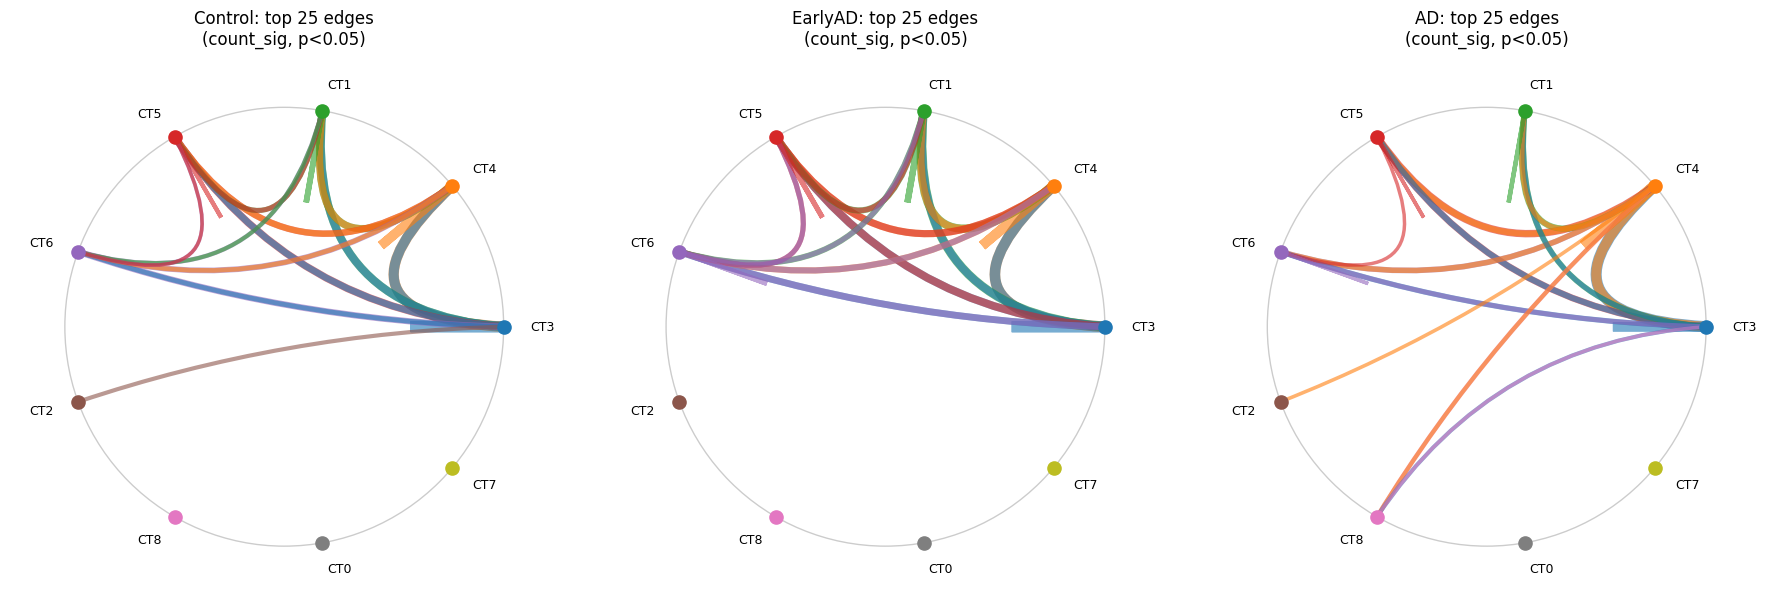

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch


paths = {
    "Control":  "/content/drive/MyDrive/PhD Research/TiissueAgent/Cell-cell communication/lr_results_control.csv",
    "EarlyAD":  "/content/drive/MyDrive/PhD Research/TiissueAgent/Cell-cell communication/lr_results_earlyAD.csv",
    "AD":       "/content/drive/MyDrive/PhD Research/TiissueAgent/Cell-cell communication/lr_results_AD.csv",
}

p_thr = 0.05
top_k_edges = 25
metric = "count_sig"                  # "count_sig" or "sum_strength"
use_pval_filter_for_strength = True   # only used for sum_strength

celltype_names = None  # e.g. ["Astro", "Micro", ..., "Endo"]

# Styling
node_radius = 1.0
control_radius = 0.15
min_lw, max_lw = 0.5, 8.0
alpha = 0.60
pad = 1.25

def pol2xy(theta, r=1.0):
    return np.array([r * np.cos(theta), r * np.sin(theta)])

def chord_path(p0, p1, cscale=0.15):
    c = (p0 + p1) * 0.5
    c = c * cscale
    verts = [tuple(p0), tuple(c), tuple(p1)]
    codes = [Path.MOVETO, Path.CURVE3, Path.CURVE3]
    return Path(verts, codes)

def compute_edges(df):
    df = df.copy()
    df["source"] = df["source"].astype(int)
    df["target"] = df["target"].astype(int)

    if metric == "count_sig":
        d = df[df["cellphone_pvals"] < p_thr]
        edges = d.groupby(["source", "target"]).size().reset_index(name="weight")

    elif metric == "sum_strength":
        d = df.copy()
        d["strength"] = 1.0 - pd.to_numeric(d["magnitude_rank"], errors="coerce")
        if use_pval_filter_for_strength:
            d = d[d["cellphone_pvals"] < p_thr]
        edges = d.groupby(["source", "target"])["strength"].sum().reset_index(name="weight")

    else:
        raise ValueError("metric must be 'count_sig' or 'sum_strength'")

    return edges

def draw_chord(ax, edges, node_order, angles, sender_color, labels, title):
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=12)

    # Line width scaling per panel (or make global if you prefer)
    w = edges["weight"].to_numpy(dtype=float)
    if len(w) == 0:
        ax.text(0, 0, "No edges\n(check p_thr/top_k)", ha="center", va="center")
        return

    wmin, wmax = w.min(), w.max()
    def scale_lw(val):
        if wmax == wmin:
            return (min_lw + max_lw) / 2
        return min_lw + (max_lw - min_lw) * (val - wmin) / (wmax - wmin)

    # Outer circle
    circle = plt.Circle((0, 0), node_radius, fill=False, lw=1.0, alpha=0.2)
    ax.add_patch(circle)

    # Nodes + labels
    for n in node_order:
        th = angles[n]
        p = pol2xy(th, node_radius)
        ax.scatter(p[0], p[1], s=90, color=sender_color[n], zorder=3)

        pl = pol2xy(th, node_radius * 1.12)
        ha = "left" if np.cos(th) >= 0 else "right"
        ax.text(pl[0], pl[1], labels[n], ha=ha, va="center", fontsize=9)

    # Chords (top K edges)
    edges = edges.sort_values("weight", ascending=False).head(top_k_edges)
    for _, r in edges.iterrows():
        s = int(r["source"])
        t = int(r["target"])
        wt = float(r["weight"])

        p0 = pol2xy(angles[s], node_radius)
        p1 = pol2xy(angles[t], node_radius)

        path = chord_path(p0, p1, cscale=control_radius)
        patch = PathPatch(
            path,
            facecolor="none",
            edgecolor=sender_color[s],   # color by sender
            lw=scale_lw(wt),
            alpha=alpha,
            zorder=2,
            capstyle="round",
        )
        ax.add_patch(patch)

    ax.set_xlim(-pad, pad)
    ax.set_ylim(-pad, pad)

# -------------------------
# 2) Load all stages
# -------------------------
dfs = {stage: pd.read_csv(fp) for stage, fp in paths.items()}

# Union of nodes across all stages
all_nodes = sorted(set(np.concatenate([dfs[s]["source"].astype(int).unique() for s in dfs] +
                                      [dfs[s]["target"].astype(int).unique() for s in dfs])))

# Labels
if celltype_names is None:
    labels = {n: f"CT{n}" for n in all_nodes}
else:
    labels = {n: celltype_names[n] for n in all_nodes}

# Compute edges per stage
edges_by_stage = {stage: compute_edges(df) for stage, df in dfs.items()}

# Choose ONE consistent node order for all panels (based on total traffic across stages)
traffic = {n: 0.0 for n in all_nodes}
for stage, ed in edges_by_stage.items():
    for _, r in ed.iterrows():
        s, t, w = int(r["source"]), int(r["target"]), float(r["weight"])
        traffic[s] += w
        traffic[t] += w
node_order = sorted(all_nodes, key=lambda n: traffic[n], reverse=True)

# Consistent angles + colors across all panels
N = len(node_order)
angles = {n: (2 * np.pi * i / N) for i, n in enumerate(node_order)}
cmap = plt.get_cmap("tab10")
sender_color = {n: cmap(i % 10) for i, n in enumerate(node_order)}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

for ax, stage in zip(axes, ["Control", "EarlyAD", "AD"]):
    title = f"{stage}: top {top_k_edges} edges\n({metric}, p<{p_thr})"
    draw_chord(ax, edges_by_stage[stage], node_order, angles, sender_color, labels, title)

plt.show()


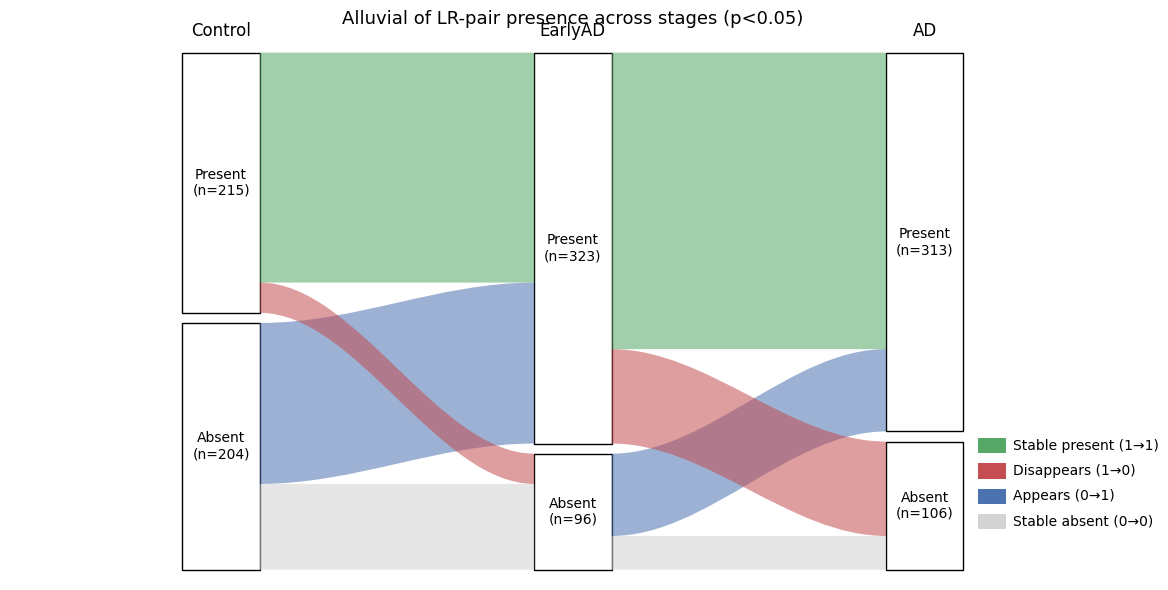

Pattern counts (Control, EarlyAD, AD):
pattern
000      8
001     63
010     70
011     63
100     20
101      5
110      8
111    182
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Rectangle


paths = {
    "Control":  "/content/drive/MyDrive/PhD Research/TiissueAgent/Cell-cell communication/lr_results_control.csv",
    "EarlyAD":  "/content/drive/MyDrive/PhD Research/TiissueAgent/Cell-cell communication/lr_results_earlyAD.csv",
    "AD":       "/content/drive/MyDrive/PhD Research/TiissueAgent/Cell-cell communication/lr_results_AD.csv",
}

p_thr = 0.05

# Optional additional filter (set to None to disable)
# magnitude_rank in LIANA is a consensus rank (smaller is better)
mag_rank_thr = None   # e.g., 0.05

# Plot settings
figsize = (12, 6)
gap = 0.02            # vertical gap between blocks (as fraction of total height)
block_width = 0.22
curve = 0.35          # curvature of ribbons (0..1)

def stage_present_set(df: pd.DataFrame, p_thr=0.05, mag_rank_thr=None) -> set:
    d = df.copy()
    d["magnitude_rank"] = pd.to_numeric(d["magnitude_rank"], errors="coerce")
    d["cellphone_pvals"] = pd.to_numeric(d["cellphone_pvals"], errors="coerce")
    d["lr_pair"] = d["ligand_complex"].astype(str) + " → " + d["receptor_complex"].astype(str)

    # aggregate per LR pair across all source/target edges
    g = d.groupby("lr_pair", as_index=False).agg(
        best_pval=("cellphone_pvals", "min"),
        best_mag_rank=("magnitude_rank", "min"),
    )

    keep = g["best_pval"] < p_thr
    if mag_rank_thr is not None:
        keep &= g["best_mag_rank"] <= mag_rank_thr

    return set(g.loc[keep, "lr_pair"].tolist())

dfs = {stage: pd.read_csv(fp) for stage, fp in paths.items()}
present = {
    stage: stage_present_set(dfs[stage], p_thr=p_thr, mag_rank_thr=mag_rank_thr)
    for stage in paths
}

# Universe = all LR pairs seen in any stage (so absent/present is well-defined)
all_pairs = set()
for stage in paths:
    d = dfs[stage].copy()
    d["lr_pair"] = d["ligand_complex"].astype(str) + " → " + d["receptor_complex"].astype(str)
    all_pairs |= set(d["lr_pair"].unique().tolist())

stages = list(paths.keys())

# Presence matrix: rows = LR pairs, cols = stages (0/1)
pairs_list = sorted(all_pairs)
P = pd.DataFrame(index=pairs_list, columns=stages, data=0, dtype=int)
for stage in stages:
    P.loc[P.index.isin(present[stage]), stage] = 1


# For each stage, counts of absent/present
counts = {}
for stage in stages:
    counts[(stage, 0)] = int((P[stage] == 0).sum())
    counts[(stage, 1)] = int((P[stage] == 1).sum())

# For each adjacent transition, counts of (from_state -> to_state)
transitions = {}
for s0, s1 in zip(stages[:-1], stages[1:]):
    key = (s0, s1)
    transitions[key] = {}
    for a in [0, 1]:
        for b in [0, 1]:
            transitions[key][(a, b)] = int(((P[s0] == a) & (P[s1] == b)).sum())

# -------------------------
# 3) Geometry: block y-ranges + subdivision y-ranges for ribbons
# -------------------------
TOTAL = len(P)

def block_ranges(stage):
    # Two blocks stacked: Absent (0) then Present (1)
    # Use a small gap between them
    n0 = counts[(stage, 0)]
    n1 = counts[(stage, 1)]
    g = gap * TOTAL

    y0_low = 0
    y0_high = n0

    y1_low = n0 + g
    y1_high = n0 + g + n1

    return {0: (y0_low, y0_high), 1: (y1_low, y1_high)}

# Subdivision ranges for outgoing (left side) and incoming (right side)
# We’ll stack in a consistent order so ribbons don’t overlap weirdly.

def outgoing_subranges(stage_left, stage_right):
    """
    For stage_left blocks, split each (abs/pres) into parts going to stage_right states (0 then 1).
    Returns dict: (from_state, to_state) -> (y_low, y_high) at x_left.
    """
    br = block_ranges(stage_left)
    out = {}
    for a in [0, 1]:
        y = br[a][0]
        for b in [0, 1]:
            h = transitions[(stage_left, stage_right)][(a, b)]
            out[(a, b)] = (y, y + h)
            y += h
    return out

def incoming_subranges(stage_left, stage_right):
    """
    For stage_right blocks, split each (abs/pres) into parts coming from stage_left states (0 then 1).
    Returns dict: (from_state, to_state) -> (y_low, y_high) at x_right.
    """
    br = block_ranges(stage_right)
    inc = {}
    for b in [0, 1]:
        y = br[b][0]
        for a in [0, 1]:
            h = transitions[(stage_left, stage_right)][(a, b)]
            inc[(a, b)] = (y, y + h)
            y += h
    return inc


def ribbon(ax, x0, x1, y0a, y0b, y1a, y1b, color, alpha=0.55, curve=0.35):
    """
    Draw a filled ribbon from [y0a,y0b] at x0 to [y1a,y1b] at x1.
    """
    dx = x1 - x0
    c0 = x0 + curve * dx
    c1 = x1 - curve * dx

    verts = [
        (x0, y0a),
        (c0, y0a),
        (c1, y1a),
        (x1, y1a),
        (x1, y1b),
        (c1, y1b),
        (c0, y0b),
        (x0, y0b),
        (x0, y0a),
    ]
    codes = [
        Path.MOVETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.LINETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.CLOSEPOLY
    ]
    patch = PathPatch(Path(verts, codes), facecolor=color, edgecolor="none", alpha=alpha)
    ax.add_patch(patch)

# -------------------------
# 5) Plot
# -------------------------
fig, ax = plt.subplots(figsize=figsize)

x_positions = {stages[0]: 0.0, stages[1]: 1.0, stages[2]: 2.0}
colors = {
    (0, 0): "lightgray",   # absent -> absent
    (0, 1): "#4C72B0",     # absent -> present (appears)
    (1, 0): "#C44E52",     # present -> absent (disappears)
    (1, 1): "#55A868",     # present -> present
}

# Draw blocks + labels
for stage in stages:
    x = x_positions[stage]
    br = block_ranges(stage)

    for state in [0, 1]:
        y0, y1 = br[state]
        rect = Rectangle((x - block_width/2, y0), block_width, y1 - y0,
                         facecolor="white", edgecolor="black", linewidth=1.0)
        ax.add_patch(rect)

        label = "Absent" if state == 0 else "Present"
        ax.text(x, (y0 + y1)/2, f"{label}\n(n={counts[(stage,state)]})",
                ha="center", va="center", fontsize=10)

    ax.text(x, TOTAL + (gap*TOTAL)*2.2, stage, ha="center", va="bottom", fontsize=12)

# Draw ribbons between Control->EarlyAD and EarlyAD->AD
for (s0, s1) in [(stages[0], stages[1]), (stages[1], stages[2])]:
    x0, x1 = x_positions[s0] + block_width/2, x_positions[s1] - block_width/2
    out = outgoing_subranges(s0, s1)
    inc = incoming_subranges(s0, s1)

    # Draw in an order that tends to look nice
    for a in [0, 1]:
        for b in [0, 1]:
            y0a, y0b = out[(a, b)]
            y1a, y1b = inc[(a, b)]
            if (y0b - y0a) <= 0:
                continue
            ribbon(ax, x0, x1, y0a, y0b, y1a, y1b,
                   color=colors[(a, b)], alpha=0.55, curve=curve)

# Ax formatting
ax.set_xlim(-0.6, 2.6)
ax.set_ylim(-TOTAL*0.02, TOTAL + (gap*TOTAL)*3)
ax.axis("off")

title_extra = f"(p<{p_thr}" + (f", mag_rank<={mag_rank_thr}" if mag_rank_thr is not None else "") + ")"
ax.set_title(f"Alluvial of LR-pair presence across stages {title_extra}", fontsize=13)

# Legend
legend_items = [
    ("Stable absent (0→0)", colors[(0,0)]),
    ("Appears (0→1)",       colors[(0,1)]),
    ("Disappears (1→0)",    colors[(1,0)]),
    ("Stable present (1→1)",colors[(1,1)]),
]
lx, ly = 2.15, TOTAL * 0.08
for i, (txt, col) in enumerate(legend_items):
    ax.add_patch(Rectangle((lx, ly + i*TOTAL*0.05), 0.08, TOTAL*0.03, facecolor=col, edgecolor="none"))
    ax.text(lx + 0.10, ly + i*TOTAL*0.05 + TOTAL*0.015, txt, va="center", fontsize=10)

plt.tight_layout()
plt.show()

# -------------------------
# 6) Optional: print pattern counts (000..111)
# -------------------------
P["pattern"] = P[stages[0]].astype(str) + P[stages[1]].astype(str) + P[stages[2]].astype(str)
pat_counts = P["pattern"].value_counts().sort_index()
print("Pattern counts (Control, EarlyAD, AD):")
print(pat_counts)
